# Figure3_1

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure3")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from pingouin import bayesfactor_binom

from functions.load_data import loadTrials, loadTrialsM, session_table
from functions.utils import first_trial_accuracy
from functions.plotting import set_paper_theme

set_paper_theme(tick_width=0.3)


In [3]:
# Texform session files come from the curated session sheet
# (data_behavior/Monkey_sessions.xlsx); within each subject/task the row
# order is the original session order (texform sessions carry no `learned`
# flag, so they cannot be selected through loadTrialsM's islearn filter).
TEXFORM_TASKS = [
    "animate_vs_inanimate_texform1",
    "animate_vs_inanimate_texform2",
    "animate_vs_inanimate_texform3",
]

_texform_rows = session_table("Monkey")
_texform_rows = _texform_rows[_texform_rows["task"].isin(TEXFORM_TASKS)]
_texform_sessions = {
    monkey: {
        task: [f"data_behavior/Monkey/{task}/{fn}" for fn in per_task["filename"]]
        for task, per_task in grp.groupby("task", sort=False)
    }
    for monkey, grp in _texform_rows.groupby("subject", sort=False)
}
Elsa, Judy, Olaf = (_texform_sessions[m] for m in ("Elsa", "Judy", "Olaf"))


In [4]:

cr_all = []
se_all = []
for task in ["animate_vs_inanimate_texform1","animate_vs_inanimate_texform2","animate_vs_inanimate_texform3"]:
    cr_task = []
    se_task = []
    for monkey in [Elsa,Judy,Olaf]:
        file = monkey[task][0]
        trials = loadTrials(file)
        trials_gen = [trial for trial in trials if trial["trial_type"]=="gen"]
        cr,se,first_trial_result = first_trial_accuracy(trials_gen)

        # binomial test against chance + Bayes factor
        result = binomtest(int(np.sum(first_trial_result)), n=len(first_trial_result), p=0.5, alternative='greater')
        bf10 = bayesfactor_binom(int(np.sum(first_trial_result)), n=len(first_trial_result), p=0.5)

        print(f"{task} P_value:{result.pvalue:.4} Bayes Factor BF_01: {1/bf10:.4}")

        cr_task.append(cr)
        se_task.append(se)
    cr_all.append(cr_task)
    se_all.append(se_task)


animate_vs_inanimate_texform1 P_value:3.836e-10 Bayes Factor BF_01: 2.043e-08
animate_vs_inanimate_texform1 P_value:1.543e-08 Bayes Factor BF_01: 7.822e-07
animate_vs_inanimate_texform1 P_value:0.0005329 Bayes Factor BF_01: 0.02049
animate_vs_inanimate_texform2 P_value:0.2595 Bayes Factor BF_01: 4.656
animate_vs_inanimate_texform2 P_value:0.5513 Bayes Factor BF_01: 6.257
animate_vs_inanimate_texform2 P_value:0.8169 Bayes Factor BF_01: 4.656
animate_vs_inanimate_texform3 P_value:0.0775 Bayes Factor BF_01: 1.907
animate_vs_inanimate_texform3 P_value:2.112e-05 Bayes Factor BF_01: 0.0009178
animate_vs_inanimate_texform3 P_value:1.592e-06 Bayes Factor BF_01: 7.404e-05


In [5]:
def plot_texform_generalization(n):
    stage_names = ["image_to_texform", "learning_start", "texform_to_texform"]
    cr_task = cr_all[n]
    fig,ax = plt.subplots(layout="none")
    fig.set(figwidth=32/75,figheight=30/75)
    # no layout engine: constrained_layout breaks on this tiny figure once title/tick labels are added.
    # Fill the whole figure with the axes so the panel keeps its physical size;
    # labels hanging outside are captured by bbox_inches="tight" at savefig.
    fig.subplots_adjust(left=0,right=1,top=1,bottom=0)

    color = [("black",1),("black",0.3),("black",0.7)]
    ax.bar(range(3),cr_task,width=0.5,color=color,yerr=se_all[n],error_kw={"linewidth":0.5})
    ax.axhline(0.5,color="black",linestyle="--",linewidth=0.5)
    ax.set_xticks(range(3),["El","Ju","Ol"])
    ax.set_xlabel("Monkeys")
    ax.set_xlim([-0.5,2.5]) 
    ax.set_ylabel("P(correct)")
    ax.set_yticks([0.4,0.6,0.8,1])
    ax.set_ylim(0.4,1) 
    # rc_context: keep the layout engine off for the inline plt.show() render
    # (savefig with bbox_inches="tight" would otherwise re-attach it).
    with plt.rc_context({"figure.constrained_layout.use": False}):
        plt.savefig(FIGURE_OUTPUT_DIR / f"texform_{stage_names[n]}.pdf", bbox_inches="tight")
    plt.show()


## Panel B - Initial generalization to texform set 1

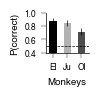

In [6]:
plot_texform_generalization(0)

## Panel C - Texform set 2 learning curves

In [7]:
task_list  = ["animate_vs_inanimate","human_vs_monkey","monkey_vs_mammal","mammal_vs_reptile","natural_vs_artificial","electronics_vs_tools"]

lr_categorical = []
for monkey in ["Elsa","Judy","Olaf"]:
    lr_monkey = []
    for i,task in enumerate(task_list):
        trials,_ = loadTrialsM(task,monkey,islearn=False,extend=False)
        lr_monkey_task = [np.mean([tr["result"]=="CORRECT" for tr in trials[n]]) for n in range(4)]
        lr_monkey.append(lr_monkey_task)
    lr_categorical.append(np.mean(lr_monkey,axis=0))

In [8]:
monkeys = ["Elsa","Judy","Olaf"]
lr_all = []
res_all = []
for i,monkey in enumerate([Elsa,Judy,Olaf]):
    lr = []
    res = []
    for file in monkey["animate_vs_inanimate_texform2"]:
        trials=loadTrials(file)
        trials_gen = [trial for trial in trials if trial["trial_type"]=="gen"] 
        cr = np.mean([trial["result"]=="CORRECT" for trial in trials_gen])
        lr.append(cr)
        res.append([trial["result"]=="CORRECT" for trial in trials_gen])
    res_all.append(res)
    lr_all.append(lr)

In [9]:

print("Texform L2; Binomial Test")
for i,monkey in enumerate(["Elsa","Judy","Olaf"]):
    for j in range(4):
        res = res_all[i][j]
        result = binomtest(int(np.sum(res)), n=len(res), p=lr_categorical[i][j], alternative='less')

        print(f"{monkey} Day{j+1} Categorical_P:{lr_categorical[i][j]:.4} P_value:{result.pvalue:.4}")


Texform L2; Binomial Test
Elsa Day1 Categorical_P:0.6417 P_value:0.0009507
Elsa Day2 Categorical_P:0.7834 P_value:4.039e-26
Elsa Day3 Categorical_P:0.8494 P_value:6.975e-66
Elsa Day4 Categorical_P:0.8739 P_value:1.535e-109
Judy Day1 Categorical_P:0.6282 P_value:0.0004962
Judy Day2 Categorical_P:0.8084 P_value:9.107e-43
Judy Day3 Categorical_P:0.8883 P_value:7.649e-49
Judy Day4 Categorical_P:0.9091 P_value:4.972e-29
Olaf Day1 Categorical_P:0.7097 P_value:1.574e-14
Olaf Day2 Categorical_P:0.8361 P_value:1.215e-44
Olaf Day3 Categorical_P:0.9071 P_value:2.779e-56
Olaf Day4 Categorical_P:0.9299 P_value:4.74e-50


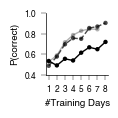

In [10]:
fig,ax = plt.subplots()
fig.set(figwidth=80/75,figheight=80/75)

ax.set_ylim(0.4,1) 
ax.set_yticks([0.4,0.6,0.8,1])
ax.set_xticks(range(8),[1,2,3,4,5,6,7,8])
ax.set_ylabel("P(correct)")
ax.set_xlabel("#Training Days")
colors = [("black",1),("black",0.3),("black",0.7)]

i = 0
lr = lr_all[i]
ax.plot(range(len(lr)),lr,linewidth=1,label=monkeys[i],color=colors[i])
ax.scatter(range(len(lr)),lr,linewidth=1,label=monkeys[i],color=colors[i],edgecolors='None',s=10)

i = 1
lr = lr_all[i]
ax.plot(range(len(lr)),lr,linewidth=1,label=monkeys[i],color=colors[i])
ax.scatter(range(len(lr)),lr,linewidth=1,label=monkeys[i],color=colors[i],edgecolors='None',s=10)

i = 2
lr = lr_all[i]
ax.plot(range(len(lr)),lr,linewidth=1,label=monkeys[i],color=colors[i],linestyle="--")
ax.scatter(range(len(lr)),lr,linewidth=1,label=monkeys[i],color=colors[i],edgecolors='None',s=10)

plt.savefig(FIGURE_OUTPUT_DIR / f"texform_learning_curve.pdf")
plt.show()

## Panel D - Generalization to texform set 1

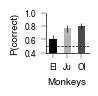

In [11]:
plot_texform_generalization(2)